# Dengue - Propuesta Machine learning
## Sergio Ballesteros

En este Jupyter esta el codigo de exploracion, tratamiento, modelado, entrenamiento, validacion e inferencia de datos sobre el **dengue** para construir un modelo predictivo en Colombia.

---
🦟 **Caracterizacion del zancudo (Aedes aegypti)**

- Eclosion de huevos en condiciones favorables toma 7 a 10 dias.
- Su Temperatura favorita 25 - 28%
- Altitud favorita <1500 m.s.n.m pero hay registros hasta 2300 m.s.n.m
- Lluvia o humedad necesaria para eclosion de huevos.
- Agua estancada es su lugar favorito.

🤒 **Caracterizacion Dengue**

- Sintomas entre 10 a 12 dias despues de la picadura infecciosa
- Al ser endemico no hay preferencia entre generos, edades, raza.

---

**Marco de trabajo**

- **Escala temporal:** Semanas
- **Escala espacial:** Municipio
- **Hoirizonte de prediccion:** 3 semanas
- **Prediccion:** Numero de casos futuro por municipio



# Objetivo del proyecto y mapa del pipeline

## Objetivo de negocio
Anticipar el riesgo de brote de dengue por municipio en Colombia con suficiente antelación para que las secretarías de salud actúen (control vectorial, capacidad hospitalaria). Es la misma pregunta de negocio del pipeline mensual del equipo (rama `main`: Poisson/XGBoost/LightGBM/GAM + FastAPI + tablero), pero aquí se explora una variante **paralela e independiente**, con granularidad **diaria** en vez de mensual.

## Objetivo de Machine Learning
Predecir `casos_dengue` confirmados (SIVIGILA) por municipio a **21 días** de horizonte, a partir de una ventana de entrada de **28 días** de variables climáticas (ERA5/CHIRPS vía Google Earth Engine) + historial de casos, con una red LSTM + embedding de municipio, optimizada con pérdida Poisson (el target es un conteo, no una probabilidad de alerta binaria).

> Nota de consistencia: el marco de trabajo de la celda de introducción fija un horizonte de "3 semanas". `HORIZON = 21` días es exactamente eso. Es más corto que el rango operativo de 4-8 semanas que usa el pipeline mensual del equipo — es una diferencia de alcance intencional de esta exploración diaria, a discutir si en el futuro se integran ambos enfoques.

## Las 7 etapas del pipeline, y qué está resuelto

| # | Etapa | Estado | Dónde |
|---|-------|--------|-------|
| 1 | Ingesta | ✅ Resuelta | Sección 0 (kagglehub, 3 CSV) |
| 2 | Exploración | ✅ Resuelta | Secciones 1.0, 1.1, 3.1 |
| 3 | Normalización (limpieza/estandarización) | ✅ Resuelta | Sección 2 (fechas, DIVIPOLA, agregación diaria, merge con calendario GEE) |
| 4 | Ingeniería de características | ✅ Resuelta | Secciones 3.0 (features derivadas), 4 (split temporal sin fuga), 5 (imputación + escalado fit solo en train), 6 (secuencias 28→21), 7 (embedding de municipio) |
| 5 | Entrenamiento | 🟡 Parcial | Arquitectura y `compile()` en Sección 8 (ya resuelta). El *loop* de entrenamiento, callbacks y búsqueda de hiperparámetros son el contenido nuevo de este notebook: Secciones 9-12 |
| 6 | Validación / testing | ⬜ Pendiente | `validation_lstm`/`test_lstm` ya existen (Sección 4) pero nunca se corrió el modelo sobre ellos. Se agrega en Sección 13 |
| 7 | Performance y métricas | ⬜ Pendiente | Se agrega en Sección 13 (métricas + gráficos), 14 (artefactos) y 15 (inferencia end-to-end) |

## Qué se agrega a partir de aquí
Bootstrap de Colab → registro en MLflow (experimento `sat-dengue`, compartido con el resto del equipo) → entrenamiento base → búsqueda de hiperparámetros (Keras Tuner) → entrenamiento final → evaluación → artefactos en `models/lstm/` → función de inferencia.

In [1]:
import pandas as pd

mapa_pipeline = pd.DataFrame([
    {"etapa": "1. Ingesta",                      "estado": "resuelta",  "seccion": "0"},
    {"etapa": "2. Exploración",                  "estado": "resuelta",  "seccion": "1.0, 1.1, 3.1"},
    {"etapa": "3. Normalización",                "estado": "resuelta",  "seccion": "2"},
    {"etapa": "4. Ingeniería de características","estado": "resuelta",  "seccion": "3.0, 4, 5, 6, 7"},
    {"etapa": "5. Entrenamiento",                 "estado": "parcial",   "seccion": "8 (arquitectura) + 9-12 (nuevo)"},
    {"etapa": "6. Validación/testing",            "estado": "pendiente", "seccion": "13 (nuevo)"},
    {"etapa": "7. Performance y métricas",        "estado": "pendiente", "seccion": "13, 14, 15 (nuevo)"},
])
mapa_pipeline

,etapa,estado,seccion
0,1. Ingesta,resuelta,0
1,2. Exploración,resuelta,"1.0, 1.1, 3.1"
2,3. Normalización,resuelta,2
3,4. Ingeniería de características,resuelta,"3.0, 4, 5, 6, 7"
4,5. Entrenamiento,parcial,8 (arquitectura) + 9-12 (nuevo)
5,6. Validación/testing,pendiente,13 (nuevo)
6,7. Performance y métricas,pendiente,"13, 14, 15 (nuevo)"


# Entorno de ejecución (Google Colab)

Este notebook está pensado para correr en Colab. Si se ejecuta localmente (venv del repo ya configurado), esta sección se auto-detecta y no hace nada destructivo. Configura, en este orden: repo + dependencias, credenciales de Kaggle, y (opcional) Google Drive para persistir artefactos entre sesiones, porque el entrenamiento de las Secciones 9-15 puede tomar varias horas y el disco de Colab es efímero.

In [2]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Ejecutando en Colab:", IN_COLAB)

Ejecutando en Colab: True


In [39]:
from pathlib import Path

REPO_URL = "https://github.com/j-mauro-r/microproyecto-tema3.git"
REPO_BRANCH = "sergio-dev"  # cambiar a "main" cuando este trabajo se integre ahi
REPO_DIR = Path("/content/microproyecto-tema3")

if IN_COLAB:
    if not REPO_DIR.exists():
        !git clone -b {REPO_BRANCH} {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}/notebooks
    !pip install -q kagglehub==1.0.2 mlflow-skinny==2.22.0 keras-tuner==1.4.8
else:
    print("Entorno local: se asume venv del repo ya instalado (requirements.txt + keras-tuner).")

/content/microproyecto-tema3/notebooks


In [5]:
import os

if IN_COLAB:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
else:
    from dotenv import load_dotenv
    load_dotenv()  # espera KAGGLE_USERNAME/KAGGLE_KEY en .env, igual que el resto del equipo

print("Credenciales Kaggle configuradas:", bool(os.environ.get("KAGGLE_KEY")))

SecretNotFoundError: Secret KAGGLE_USERNAME does not exist.

In [6]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ARTIFACTS = Path("/content/drive/MyDrive/sat-dengue-lstm")
    DRIVE_ARTIFACTS.mkdir(parents=True, exist_ok=True)
else:
    DRIVE_ARTIFACTS = None

print("Directorio de respaldo persistente:", DRIVE_ARTIFACTS)

Mounted at /content/drive
Directorio de respaldo persistente: /content/drive/MyDrive/sat-dengue-lstm


In [7]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPUs detectadas:", gpus)
if not gpus:
    print(
        "ADVERTENCIA: activa Entorno de ejecucion > Cambiar tipo de entorno > GPU. "
        "Sin GPU, el entrenamiento de las Secciones 10-12 puede no terminar dentro "
        "de una sesion de Colab."
    )

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 0. Descarga de datos
---
Los datos estan cargados en Kaggle, solo agregue su token legacy.

**Fuente:** SIVIGILA - Microdatos - Dengue

- Dengue 2007 - 2025 (Caso a caso con fecha y lugar)

**Fuente:** SIVIGILA - Microdatos - Dengue Grave

- Dengue Grave 2007 -2005 (Caso a caso con fecha y lugar)

**Fuente:** Google Earth Engine dataset ERA5 y CHRISP

- Google Eart Engine ERA5 | CHRISP 2007 - 2025 (Variables climaticas diarias)

In [8]:
import shutil
from pathlib import Path
import kagglehub

# Ruta local para almacenar los datos crudos
ruta_raw = Path.cwd().parent / "data" / "raw"
ruta_raw.mkdir(parents=True, exist_ok=True)

# Descargar última versión del dataset
path = Path(
    kagglehub.dataset_download(
        "saballesteros/maia4331-2614-grupo19"
    )
)

# Copiar archivos CSV al directorio raw
for archivo in path.glob("*.csv"):
    shutil.copy2(archivo, ruta_raw / archivo.name)

print("Archivos guardados en:", ruta_raw)

100%|██████████| 808M/808M [00:44<00:00, 18.8MB/s]

Extracting files...


Archivos guardados en: /content/microproyecto-tema3/data/raw


# 1.0. Datos crudos
---
No mostre el detalle por que son 69 columnas x un millon setecientos mil datos, asi que solo le daremos un vistazo a los shapes

In [9]:

import pandas as pd
from pathlib import Path

# Ruta local de los datos crudos
ruta_raw = Path.cwd().parent / "data" / "raw"

# Cargar los archivos CSV en DataFrames de pandas
dengue = pd.read_csv(ruta_raw / "dengue.csv", low_memory=False)
dengue_grave = pd.read_csv(ruta_raw / "dengue_grave.csv", low_memory=False)
gee = pd.read_csv(ruta_raw / "google_earth_engine.csv", low_memory=False)

# lista de dataframes y sus nombres
raw_dataframes={
    "dengue": dengue,
    "dengue_grave": dengue_grave,
    "gee": gee
}

# For para mostrar la descripción de cada dataframe crudo
for nombre, df in raw_dataframes.items():
    print(f"\n===== {nombre} =====")
    print("Shape:", df.shape)


===== dengue =====
Shape: (1705604, 69)

===== dengue_grave =====
Shape: (50101, 69)

===== gee =====
Shape: (7751898, 18)


# 1.1 Exploracion de datos
---
Como lo mencione la caracterizacion del problema es diario por municipio asi que aqui estan las variables de interes, la variable confirmados seria nuestra variabvle objetivo.

Deje la variable nom_est_f_caso por una razon, mas vale prevenir que lamentar, si hay muchos casos probables entonces pues hacemos alertas asi fueran falsas, una vida no tiene precio.

In [10]:
# Variables necesarias para dengue
columnas_dengue = [
    "CONSECUTIVE", # Mas adelante lo aplanaremos por semana
    "INI_SIN", # Fecha de inicio de síntomas
    "COD_DPTO_O", # Código del departamento
    "COD_MUN_O", # Código del municipio
    "confirmados", # Número de casos confirmado etiqueta target
    "nom_est_f_caso", # Nombre estado final del caso por confirmado por nexo, laboratorio o probable
    "Nombre_evento" # Dengue o Dengue grave
]

# Variables necesarias para Google Earth Engine
columnas_gee = [
    "date", # Fecha de la observación
    "mpio_cdpmp", # Código del municipio
    "rain_mm_day",  # Precipitación diaria en mm
    "temp_mean_c", # Temperatura media en °C
    "dewpoint_mean_c", # Punto de rocío medio en °C
    "soil_water_l1_mean", # Agua en el suelo capa 1 (0-2 mt) en m3/m3
    "surface_runoff_mm_day", # Escorrentía superficial en mm/día
    "total_evaporation_mm_day_ecmwf", # Evaporación total en mm/día (ECMWF)
    "wind_u_mean_ms", # Componente U del viento en m/s
    "wind_v_mean_ms", # Componente V del viento en m/s
    "solar_radiation_mj_m2_day" # Radiación solar en MJ/m2/día
]

# Selección de columnas
dengue = dengue[columnas_dengue].copy()
dengue_grave = dengue_grave[columnas_dengue].copy()
gee = gee[columnas_gee].copy()

# Listar los archivos con las columnas seleccionadas
proc_dataframes={
    "dengue": dengue,
    "dengue_grave": dengue_grave,
    "gee": gee
}

# For para mostrar la descripción de cada dataframe procesado
for nombre, df in proc_dataframes.items():
    print(f"\n===== {nombre} =====")
    print("Shape:", df.shape)


===== dengue =====
Shape: (1705604, 7)

===== dengue_grave =====
Shape: (50101, 7)

===== gee =====
Shape: (7751898, 11)


# 2. Limpieza de datos
---
Necesitamos las fechas en un solo formato y ver nulos y duplicados.

In [11]:
import pandas as pd

# ============================================================
# 1. LIMPIEZA DE CASOS DE DENGUE
# ============================================================

def limpiar_casos(df):

    df = df.copy()

    # Conservar únicamente casos confirmados
    df = df[df["confirmados"] == 1]

    # Eliminar registros sin información necesaria
    df = df.dropna(
        subset=[
            "INI_SIN",
            "COD_DPTO_O",
            "COD_MUN_O"
        ]
    )

    # Fecha de inicio de síntomas
    df["date"] = pd.to_datetime(
        df["INI_SIN"],
        dayfirst=True,
        errors="coerce"
    )

    # Eliminar fechas que no pudieron convertirse
    df = df.dropna(subset=["date"])

    # Normalizar fecha a nivel diario
    df["date"] = df["date"].dt.normalize()

    # Construir código DIVIPOLA de 5 dígitos
    df["mpio_cdpmp"] = (
        df["COD_DPTO_O"].astype(int).astype(str).str.zfill(2)
        + df["COD_MUN_O"].astype(int).astype(str).str.zfill(3)
    )

    return df


dengue = limpiar_casos(dengue)
dengue_grave = limpiar_casos(dengue_grave)


# ============================================================
# 2. AGRUPAR CASOS POR MUNICIPIO Y DÍA
# ============================================================

casos_dengue = (
    dengue
    .groupby(["date", "mpio_cdpmp"])
    .size()
    .reset_index(name="casos_dengue")
)

casos_dengue_grave = (
    dengue_grave
    .groupby(["date", "mpio_cdpmp"])
    .size()
    .reset_index(name="casos_dengue_grave")
)


# ============================================================
# 3. LIMPIEZA GOOGLE EARTH ENGINE
# ============================================================

gee = gee.copy()

gee["date"] = pd.to_datetime(
    gee["date"],
    errors="coerce"
)

gee = gee.dropna(
    subset=[
        "date",
        "mpio_cdpmp"
    ]
)

gee["date"] = gee["date"].dt.normalize()

# Estandarizar DIVIPOLA
gee["mpio_cdpmp"] = (
    gee["mpio_cdpmp"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Eliminar duplicados municipio-fecha si existieran
gee = (
    gee
    .drop_duplicates(
        subset=["date", "mpio_cdpmp"]
    )
)


# ============================================================
# 4. CONSTRUIR DATASET BASE
# ============================================================

# GEE funciona como calendario diario municipio-fecha
dataset_base = (
    gee
    .merge(
        casos_dengue,
        on=["date", "mpio_cdpmp"],
        how="left"
    )
    .merge(
        casos_dengue_grave,
        on=["date", "mpio_cdpmp"],
        how="left"
    )
)


# ============================================================
# 5. DÍAS SIN REGISTROS DE DENGUE = 0 CASOS
# ============================================================

dataset_base[
    ["casos_dengue", "casos_dengue_grave"]
] = (
    dataset_base[
        ["casos_dengue", "casos_dengue_grave"]
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 6. ORDENAR DATASET
# ============================================================

dataset_base = (
    dataset_base
    .sort_values(["mpio_cdpmp", "date"])
    .reset_index(drop=True)
)


# ============================================================
# 7. VALIDACIÓN
# ============================================================

print("Shape:", dataset_base.shape)

print("\nRango temporal:")
print(
    dataset_base["date"].min(),
    "->",
    dataset_base["date"].max()
)

print("\nMunicipios:")
print(dataset_base["mpio_cdpmp"].nunique())

print("\nCasos:")
print(
    dataset_base[
        ["casos_dengue", "casos_dengue_grave"]
    ].sum()
)

print("\nNulos:")
print(
    dataset_base.isna()
    .sum()
    .sort_values(ascending=False)
)

/tmp/ipykernel_16454/588996427.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(
/tmp/ipykernel_16454/588996427.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(


Shape: (7751898, 13)

Rango temporal:
2007-01-01 00:00:00 -> 2025-12-31 00:00:00

Municipios:
1122

Casos:
casos_dengue          987142
casos_dengue_grave     31389
dtype: int64

Nulos:
rain_mm_day                       13818
dewpoint_mean_c                   13818
temp_mean_c                       13818
surface_runoff_mm_day             13818
soil_water_l1_mean                13818
wind_v_mean_ms                    13818
wind_u_mean_ms                    13818
total_evaporation_mm_day_ecmwf    13818
solar_radiation_mj_m2_day         12484
mpio_cdpmp                            0
date                                  0
casos_dengue                          0
casos_dengue_grave                    0
dtype: int64


# 3.0 Feature Engineering - LSTM
---
Para LSTM no necesitamos fabricar decenas de lags y medias móviles.

La red recibirá directamente una secuencia diaria de **28 días** y aprenderá la evolución temporal del clima y los casos.

Solo agregamos variables que no existen directamente en los datos: velocidad del viento y estacionalidad anual.

In [12]:
# ============================================================
# FEATURE ENGINEERING - LSTM
# ============================================================

import numpy as np


# ============================================================
# 1. ORDEN TEMPORAL
# ============================================================

dataset_base = (
    dataset_base
    .sort_values(
        ["mpio_cdpmp", "date"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 2. VELOCIDAD DEL VIENTO
# ============================================================

# GEE entrega componentes U y V.
# Para el modelo usamos la magnitud del viento.

dataset_base["wind_speed_mean_ms"] = np.sqrt(
    dataset_base["wind_u_mean_ms"] ** 2
    + dataset_base["wind_v_mean_ms"] ** 2
)


# ============================================================
# 3. ESTACIONALIDAD
# ============================================================

# La fecha es cíclica: después de diciembre vuelve enero.
# Se representa usando seno y coseno.

dataset_base["day_of_year"] = (
    dataset_base["date"]
    .dt
    .dayofyear
)

dataset_base["day_of_year_sin"] = np.sin(
    2 * np.pi
    * dataset_base["day_of_year"]
    / 365.25
)

dataset_base["day_of_year_cos"] = np.cos(
    2 * np.pi
    * dataset_base["day_of_year"]
    / 365.25
)


# ============================================================
# 4. FEATURES PARA LSTM
# ============================================================

features_lstm = [
    "rain_mm_day",
    "temp_mean_c",
    "dewpoint_mean_c",
    "soil_water_l1_mean",
    "surface_runoff_mm_day",
    "total_evaporation_mm_day_ecmwf",
    "solar_radiation_mj_m2_day",
    "wind_speed_mean_ms",
    "day_of_year_sin",
    "day_of_year_cos",

    # Historial epidemiológico
    "casos_dengue"
]


# ============================================================
# 5. DATASET PARA LSTM
# ============================================================

dataset_lstm = dataset_base[
    [
        "date",
        "mpio_cdpmp",
        *features_lstm
    ]
].copy()


# ============================================================
# 6. VALIDACIÓN
# ============================================================

print("Shape:", dataset_lstm.shape)
print("Features LSTM:", len(features_lstm))
print("\nNulos:")

print(
    dataset_lstm[features_lstm]
    .isna()
    .sum()
)

Shape: (7751898, 13)
Features LSTM: 11

Nulos:
rain_mm_day                       13818
temp_mean_c                       13818
dewpoint_mean_c                   13818
soil_water_l1_mean                13818
surface_runoff_mm_day             13818
total_evaporation_mm_day_ecmwf    13818
solar_radiation_mj_m2_day         12484
wind_speed_mean_ms                13818
day_of_year_sin                       0
day_of_year_cos                       0
casos_dengue                          0
dtype: int64


# 3.1 Analizando Features
---
Vamos a ver cómo se comportan las principales variables agrupadas por año para tener una vista general del país.

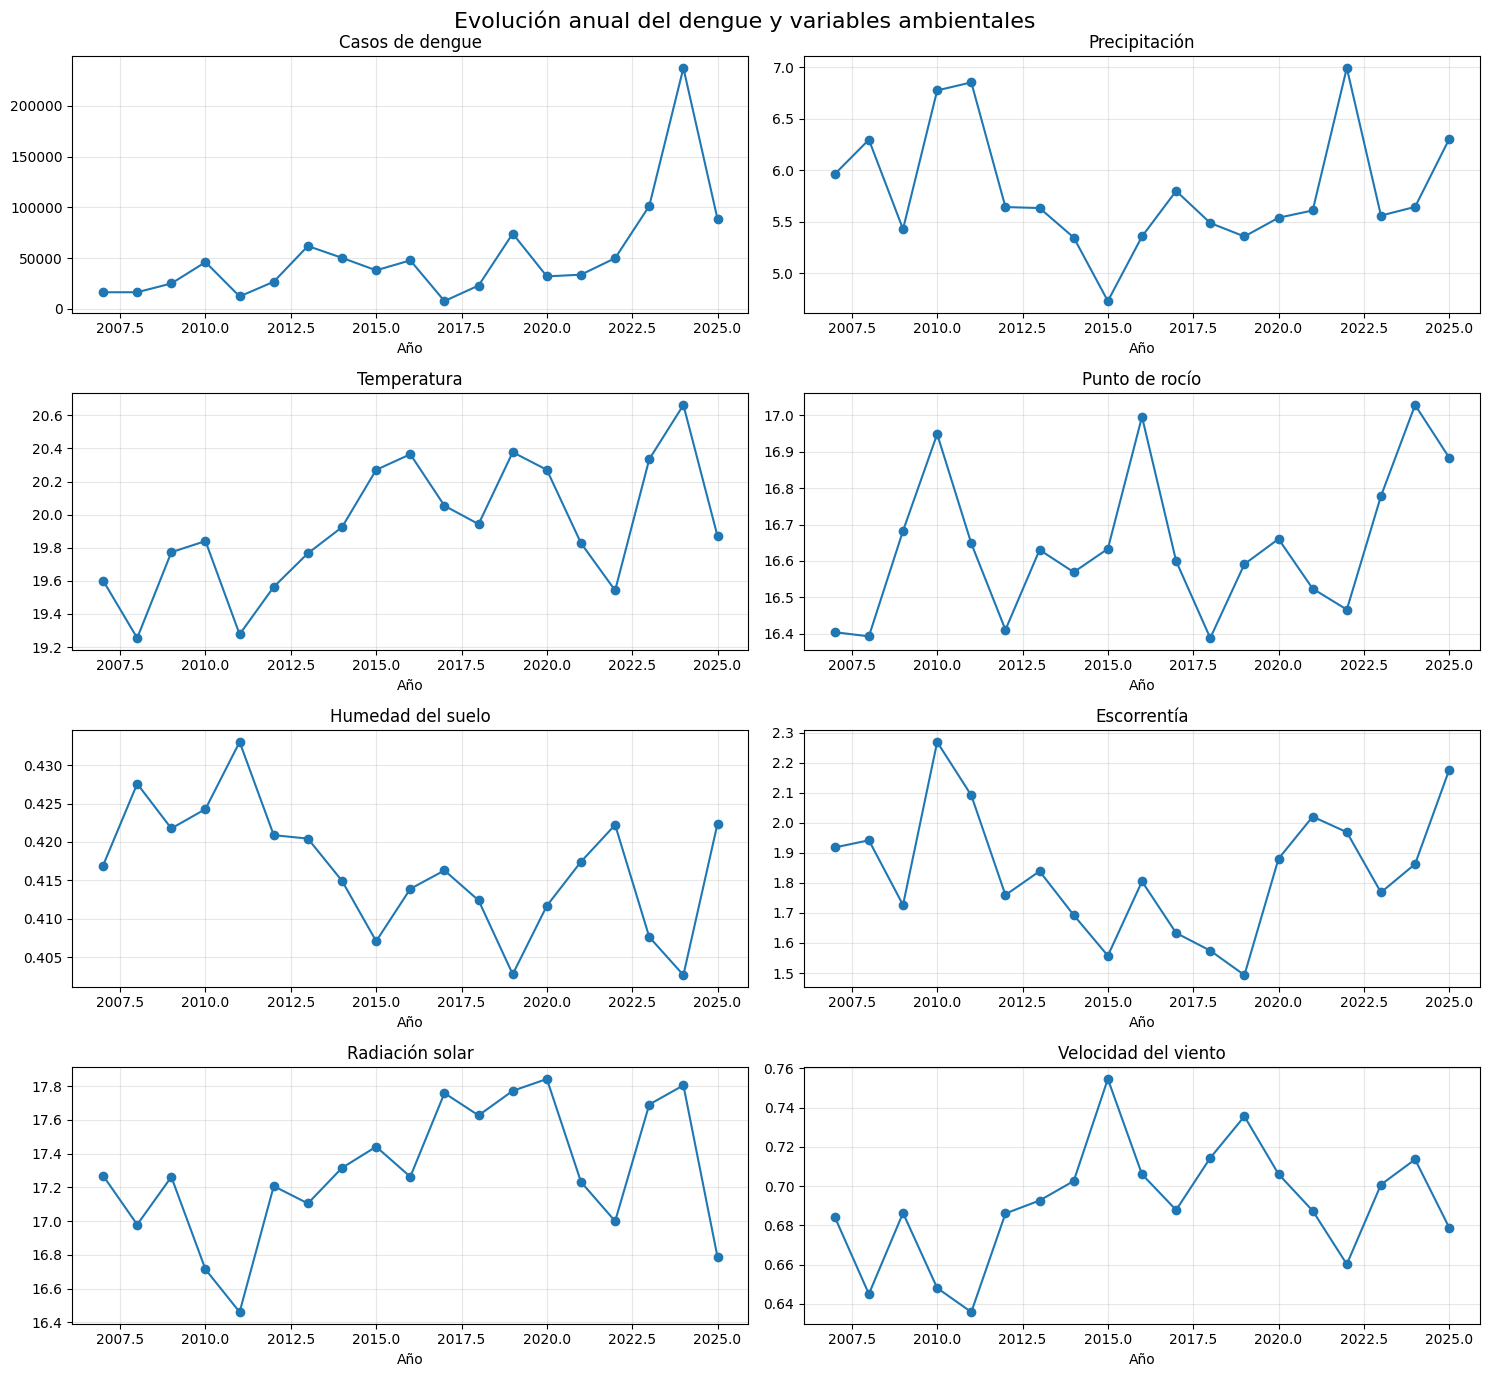

In [13]:
# ============================================================
# ANÁLISIS DE FEATURES - COMPORTAMIENTO ANUAL
# ============================================================

import math
import matplotlib.pyplot as plt


# ============================================================
# 1. VARIABLES A VISUALIZAR
# ============================================================

features = {
    "casos_dengue": "Casos de dengue",
    "rain_mm_day": "Precipitación",
    "temp_mean_c": "Temperatura",
    "dewpoint_mean_c": "Punto de rocío",
    "soil_water_l1_mean": "Humedad del suelo",
    "surface_runoff_mm_day": "Escorrentía",
    "solar_radiation_mj_m2_day": "Radiación solar",
    "wind_speed_mean_ms": "Velocidad del viento"
}


# ============================================================
# 2. CREAR AÑO
# ============================================================

dataset_base["year"] = dataset_base["date"].dt.year


# ============================================================
# 3. AGREGACIÓN ANUAL
# ============================================================

agregaciones = {
    feature: "mean"
    for feature in features
}

agregaciones["casos_dengue"] = "sum"

dataset_anual = (
    dataset_base
    .groupby("year")
    .agg(agregaciones)
    .reset_index()
)


# ============================================================
# 4. MOSAICO DE FEATURES
# ============================================================

columnas = 2
filas = math.ceil(len(features) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(15, filas * 3.5)
)

axes = axes.flatten()

for ax, (feature, titulo) in zip(axes, features.items()):

    ax.plot(
        dataset_anual["year"],
        dataset_anual[feature],
        marker="o"
    )

    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.grid(alpha=0.3)

for ax in axes[len(features):]:
    ax.remove()

plt.suptitle(
    "Evolución anual del dengue y variables ambientales",
    fontsize=16
)

plt.tight_layout()
plt.show()

# 4. Entrenamiento, validación y pruebas
---
La separación es temporal.

- **Train:** 2007 - 2023
- **Validation:** 2024
- **Test:** 2025

El horizonte de predicción será de **21 días**.

In [14]:
# ============================================================
# DIVISIÓN TEMPORAL - LSTM
# ============================================================

HORIZON = 21

# Fecha que realmente estamos intentando predecir
dataset_lstm["target_date"] = (
    dataset_lstm["date"]
    + pd.Timedelta(days=HORIZON)
)


# ============================================================
# 1. TRAIN
# ============================================================

train_lstm = dataset_lstm[
    dataset_lstm["target_date"].dt.year <= 2023
].copy()


# ============================================================
# 2. VALIDATION
# ============================================================

validation_lstm = dataset_lstm[
    dataset_lstm["target_date"].dt.year == 2024
].copy()


# ============================================================
# 3. TEST
# ============================================================

test_lstm = dataset_lstm[
    dataset_lstm["target_date"].dt.year == 2025
].copy()


# ============================================================
# 4. VALIDACIÓN
# ============================================================

for nombre, df in {
    "TRAIN": train_lstm,
    "VALIDATION": validation_lstm,
    "TEST": test_lstm
}.items():

    print(
        nombre,
        "|",
        df["target_date"].min(),
        "->",
        df["target_date"].max(),
        "|",
        df.shape
    )

TRAIN | 2007-01-22 00:00:00 -> 2023-12-31 00:00:00 | (6908154, 14)
VALIDATION | 2024-01-01 00:00:00 -> 2024-12-31 00:00:00 | (410652, 14)
TEST | 2025-01-01 00:00:00 -> 2025-12-31 00:00:00 | (409530, 14)


# 5. Preparación de datos para LSTM
---
La LSTM necesita variables en escalas comparables.

La imputación y normalización se calculan **solo con Train** para evitar `data leakage`. Validation y Test únicamente reutilizan esas estadísticas.

In [15]:
# ============================================================
# TRATAMIENTO DE NULOS Y NORMALIZACIÓN - LSTM
# ============================================================

from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. IMPUTACIÓN
# ============================================================

# Medianas calculadas únicamente con TRAIN.
medianas_train = (
    train_lstm[features_lstm]
    .median()
)

for df in [
    train_lstm,
    validation_lstm,
    test_lstm
]:
    df[features_lstm] = (
        df[features_lstm]
        .fillna(medianas_train)
    )


# ============================================================
# 2. NORMALIZACIÓN
# ============================================================

scaler = StandardScaler()

scaler.fit(
    train_lstm[features_lstm]
)

train_lstm[features_lstm] = scaler.transform(
    train_lstm[features_lstm]
)

validation_lstm[features_lstm] = scaler.transform(
    validation_lstm[features_lstm]
)

test_lstm[features_lstm] = scaler.transform(
    test_lstm[features_lstm]
)


# ============================================================
# 3. VALIDACIÓN
# ============================================================

print("Nulos Train:")
print(
    train_lstm[features_lstm]
    .isna()
    .sum()
    .sum()
)

print(
    "\nMedia aproximada Train:",
    train_lstm[features_lstm]
    .mean()
    .mean()
)

print(
    "Desviación aproximada Train:",
    train_lstm[features_lstm]
    .std()
    .mean()
)

Nulos Train:
0

Media aproximada Train: -6.822131640554766e-16
Desviación aproximada Train: 1.0000000723763607


# 6. Creación de secuencias
---
Cada observación para la LSTM tendrá:

- **28 días de historia**
- **11 variables por día**
- un objetivo: casos de dengue **21 días después**

El target se mantiene en su escala original.

In [16]:
# ============================================================
# CREACIÓN DE SECUENCIAS - LSTM
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

LOOKBACK = 28
HORIZON = 21


# ============================================================
# 2. RECONSTRUIR DATASET NORMALIZADO COMPLETO
# ============================================================

# Unimos nuevamente los tres bloques normalizados.
# Esto permite conservar continuidad temporal entre años.

dataset_scaled = pd.concat(
    [
        train_lstm,
        validation_lstm,
        test_lstm
    ],
    ignore_index=True
)

dataset_scaled = (
    dataset_scaled
    .sort_values(["mpio_cdpmp", "date"])
    .reset_index(drop=True)
)


# ============================================================
# 3. TARGET ORIGINAL SIN NORMALIZAR
# ============================================================

target_raw = (
    dataset_lstm[
        ["date", "mpio_cdpmp", "casos_dengue"]
    ]
    .rename(
        columns={
            "casos_dengue": "target_raw"
        }
    )
)

dataset_scaled = dataset_scaled.merge(
    target_raw,
    on=["date", "mpio_cdpmp"],
    how="left"
)


# ============================================================
# 4. FUNCIÓN PARA CREAR SECUENCIAS
# ============================================================

def crear_secuencias(df):

    X = []
    y = []
    municipios = []
    fechas_target = []

    for municipio, grupo in df.groupby("mpio_cdpmp"):

        grupo = (
            grupo
            .sort_values("date")
            .reset_index(drop=True)
        )

        valores = grupo[features_lstm].to_numpy(
            dtype=np.float32
        )

        target = grupo["target_raw"].to_numpy(
            dtype=np.float32
        )

        fechas = grupo["date"].to_numpy()

        limite = len(grupo) - HORIZON

        for i in range(
            LOOKBACK - 1,
            limite
        ):

            inicio = i - LOOKBACK + 1
            fin = i + 1

            target_idx = i + HORIZON

            X.append(
                valores[inicio:fin]
            )

            y.append(
                target[target_idx]
            )

            municipios.append(
                municipio
            )

            fechas_target.append(
                fechas[target_idx]
            )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(municipios),
        pd.to_datetime(fechas_target)
    )


# ============================================================
# 5. CREAR SECUENCIAS
# ============================================================

X, y, municipios_seq, fechas_target = crear_secuencias(
    dataset_scaled
)


# ============================================================
# 6. DIVIDIR POR FECHA DEL TARGET
# ============================================================

mask_train = fechas_target.year <= 2023
mask_validation = fechas_target.year == 2024
mask_test = fechas_target.year == 2025

X_train = X[mask_train]
y_train = y[mask_train]

X_validation = X[mask_validation]
y_validation = y[mask_validation]

X_test = X[mask_test]
y_test = y[mask_test]


# ============================================================
# 7. VALIDACIÓN
# ============================================================

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nShape de una secuencia:")
print(X_train[0].shape)

Train: (6877860, 28, 11) (6877860,)
Validation: (410652, 28, 11) (410652,)
Test: (385968, 28, 11) (385968,)

Shape de una secuencia:
(28, 11)


# 7. Municipio como entrada del modelo
---
Un mismo patrón climático puede comportarse distinto según el municipio.

El código DIVIPOLA no se usa como número continuo: se convierte en un ID para aprender un **embedding por municipio**.

In [17]:
# ============================================================
# PREPARACIÓN DE MUNICIPIOS PARA EMBEDDING
# ============================================================

import numpy as np


# ============================================================
# 1. MUNICIPIOS DISPONIBLES EN TRAIN
# ============================================================

municipios_train_unicos = np.unique(
    municipios_seq[mask_train]
)

municipio_to_id = {
    municipio: i + 1
    for i, municipio in enumerate(municipios_train_unicos)
}

# 0 queda reservado para municipios desconocidos
N_MUNICIPIOS = len(municipio_to_id) + 1


# ============================================================
# 2. CONVERTIR MUNICIPIO A ID NUMÉRICO
# ============================================================

municipios_ids = np.array(
    [
        municipio_to_id.get(municipio, 0)
        for municipio in municipios_seq
    ],
    dtype=np.int32
)


# ============================================================
# 3. DIVIDIR MUNICIPIOS
# ============================================================

municipio_train = municipios_ids[mask_train]

municipio_validation = municipios_ids[
    mask_validation
]

municipio_test = municipios_ids[
    mask_test
]


# ============================================================
# 4. VALIDACIÓN
# ============================================================

print("Municipios:", N_MUNICIPIOS)

print(
    "Train:",
    X_train.shape,
    municipio_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_validation.shape,
    municipio_validation.shape,
    y_validation.shape
)

print(
    "Test:",
    X_test.shape,
    municipio_test.shape,
    y_test.shape
)

Municipios: 1123
Train: (6877860, 28, 11) (6877860,) (6877860,)
Validation: (410652, 28, 11) (410652,) (410652,)
Test: (385968, 28, 11) (385968,) (385968,)


# 8. Modelo LSTM
---
La secuencia temporal aprende la evolución de clima y casos.

El embedding aprende diferencias estructurales entre municipios.

Todavía **no entrenamos**: este notebook queda hasta la definición y compilación del modelo.

In [18]:
# ============================================================
# ARQUITECTURA LSTM + EMBEDDING DE MUNICIPIO
# ============================================================

import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Embedding,
    Flatten,
    Concatenate
)


# ============================================================
# 1. ENTRADA TEMPORAL
# ============================================================

sequence_input = Input(
    shape=(LOOKBACK, len(features_lstm)),
    name="sequence"
)

x_seq = LSTM(
    units=64,
    name="lstm"
)(sequence_input)

x_seq = Dropout(
    0.2
)(x_seq)


# ============================================================
# 2. ENTRADA MUNICIPIO
# ============================================================

municipio_input = Input(
    shape=(1,),
    dtype="int32",
    name="municipio"
)

x_mpio = Embedding(
    input_dim=N_MUNICIPIOS,
    output_dim=16,
    name="municipio_embedding"
)(municipio_input)

x_mpio = Flatten()(x_mpio)


# ============================================================
# 3. COMBINAR INFORMACIÓN
# ============================================================

x = Concatenate()([
    x_seq,
    x_mpio
])

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(
    0.2
)(x)

x = Dense(
    32,
    activation="relu"
)(x)


# ============================================================
# 4. SALIDA
# ============================================================

# Softplus garantiza predicciones >= 0
output = Dense(
    1,
    activation="softplus",
    name="casos_dengue"
)(x)


# ============================================================
# 5. MODELO
# ============================================================

modelo_lstm = Model(
    inputs=[
        sequence_input,
        municipio_input
    ],
    outputs=output
)


# ============================================================
# 6. COMPILACIÓN
# ============================================================

modelo_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="poisson",

    metrics=[
        "mae"
    ]
)


# ============================================================
# 7. VALIDACIÓN
# ============================================================

modelo_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 28, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ municipio           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ municipio_embedding │ (None, 1, 16)     │     17,968 │ municipio[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ municipio_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ casos_dengue        │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,721 (174.69 KB)

 Trainable params: 44,721 (174.69 KB)

 Non-trainable params: 0 (0.00 B)

# 9. Registro de experimentos (MLflow)
---
Se usa el mismo experimento `sat-dengue` de `src/models/train.py`, con `modelo="lstm"` como parámetro para poder filtrar estas corridas junto a las de Poisson/XGBoost/LightGBM/GAM en la UI de MLflow. El tracking URI se resuelve igual que en el script del equipo (`--tracking-uri` → variable de entorno → fallback local), agregando un secreto de Colab como fuente adicional y, si no hay servidor remoto alcanzable, respaldando `./mlruns` en Drive para que las corridas sobrevivan a un reinicio del runtime.

In [49]:
import sys
for _mod in list(sys.modules):
    if _mod == "mlflow" or _mod.startswith("mlflow."):
        del sys.modules[_mod]

import sys, types
if "pyarrow.fs" not in sys.modules:
    stub = types.ModuleType("pyarrow.fs")
    stub.__getattr__ = lambda nombre: None
    sys.modules["pyarrow.fs"] = stub



In [50]:
import os
import mlflow
EXPERIMENTO = "sat-dengue"

tracking_uri = os.environ.get("MLFLOW_TRACKING_URI")

if tracking_uri is None and IN_COLAB:
    try:
        from google.colab import userdata
        tracking_uri = userdata.get("MLFLOW_TRACKING_URI")
    except Exception:
        tracking_uri = None

if tracking_uri is None and DRIVE_ARTIFACTS is not None:
    tracking_uri = f"file:{DRIVE_ARTIFACTS / 'mlruns'}"

if tracking_uri:
    mlflow.set_tracking_uri(tracking_uri)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
mlflow.set_experiment(EXPERIMENTO)

RUN_TAG_BASE = "lstm_diario_h21_l28"

MLflow tracking URI: file:/content/drive/MyDrive/sat-dengue-lstm/mlruns


2026/09/19 06:22:49 INFO mlflow.tracking.fluent: Experiment with name 'sat-dengue' does not exist. Creating a new experiment.


# 10. Entrenamiento base
---
Antes de invertir cómputo en búsqueda de hiperparámetros, se valida que toda la tubería (secuencias + embedding + arquitectura + pérdida Poisson) corre sin errores ni NaN, con pocas épocas, usando `tf.data.Dataset` en lugar de alimentar `model.fit` con los arrays de NumPy completos.

**Riesgo de memoria:** `X` (el arreglo completo antes de separarlo en train/val/test) pesa ~9.4 GB en float32, y coexiste con `X_train`/`X_validation`/`X_test` (otros ~9.4 GB) desde la celda de creación de secuencias hasta la limpieza de abajo. En un runtime de Colab con poca RAM esto puede agotar la memoria antes de llegar aquí; si eso ocurre, la única salida es adelantar manualmente un `del X; gc.collect()` justo después de crear los splits, o usar un runtime con más RAM.

In [20]:
import gc

# `X` (arreglo completo), los DataFrames intermedios de limpieza/EDA y las
# crudas de Kaggle ya cumplieron su funcion: lo que sigue vivo y se necesita
# de aqui en adelante es X_train/validation/test, municipio_train/validation/test,
# y_train/validation/test, municipios_seq, fechas_target, medianas_train, scaler,
# municipio_to_id, features_lstm, N_MUNICIPIOS.
#
# `dataset_lstm` se conserva (sin escalar) porque la Seccion 15 (inferencia) lo
# necesita para reconstruir ventanas de 28 dias "en crudo" con fechas nuevas.
for nombre in ["X", "dataset_scaled", "dataset_base",
               "dengue", "dengue_grave", "gee", "raw_dataframes", "proc_dataframes",
               "train_lstm", "validation_lstm", "test_lstm", "target_raw"]:
    if nombre in globals():
        del globals()[nombre]

gc.collect()

161

In [21]:
import tensorflow as tf

BATCH_SIZE = 1024        # secuencias livianas (28x11 floats); el cuello de botella
                          # no es la GPU, es la RAM que ya ocupan los arrays fuente
SHUFFLE_BUFFER = 200_000 # acotado a proposito: un buffer de 6.9M duplicaria X_train en RAM

def construir_dataset(X, municipio, y, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        ({"sequence": X, "municipio": municipio.reshape(-1, 1)}, y)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(SHUFFLE_BUFFER, len(y)), reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = construir_dataset(X_train, municipio_train, y_train, shuffle=True)
validation_ds = construir_dataset(X_validation, municipio_validation, y_validation)
test_ds = construir_dataset(X_test, municipio_test, y_test)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def construir_callbacks(checkpoint_path=None, patience=5):
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(2, patience // 2), min_lr=1e-6),
    ]
    if checkpoint_path is not None:
        callbacks.append(
            ModelCheckpoint(str(checkpoint_path), monitor="val_loss", save_best_only=True)
        )
    return callbacks

In [23]:
# %%time  # descomentar para medir el tiempo/epoca y dimensionar la Seccion 12

EPOCHS_BASELINE = 3

historial_base = modelo_lstm.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS_BASELINE,
    callbacks=construir_callbacks(patience=2),
    verbose=1,
)

Epoch 1/3
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - loss: 0.0803 - mae: 0.0968 - val_loss: -0.2638 - val_mae: 0.3783 - learning_rate: 0.0010
Epoch 2/3
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - loss: 0.0752 - mae: 0.0933 - val_loss: -0.2620 - val_mae: 0.3851 - learning_rate: 0.0010
Epoch 3/3
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - loss: 0.0744 - mae: 0.0927 - val_loss: -0.2598 - val_mae: 0.3876 - learning_rate: 0.0010


In [51]:
with mlflow.start_run(run_name=f"{RUN_TAG_BASE}_baseline"):
    mlflow.log_params({
        "modelo": "lstm", "fase": "baseline",
        "lookback": LOOKBACK, "horizon": HORIZON, "batch_size": BATCH_SIZE,
        "n_features": len(features_lstm), "n_municipios": N_MUNICIPIOS,
        "epochs": EPOCHS_BASELINE,
    })
    for epoca, (loss, val_loss, mae, val_mae) in enumerate(zip(
        historial_base.history["loss"], historial_base.history["val_loss"],
        historial_base.history["mae"], historial_base.history["val_mae"],
    )):
        mlflow.log_metrics({"loss": loss, "val_loss": val_loss, "mae": mae, "val_mae": val_mae}, step=epoca)

# 11. Búsqueda de hiperparámetros (Keras Tuner)
---
Se envuelve la arquitectura de dos entradas (secuencia + embedding de municipio) en una función `construir_modelo(hp)` y se busca con **Hyperband** sobre: unidades LSTM, dropout de la LSTM, dimensión del embedding de municipio, tamaño de las dos capas densas, dropout denso, y learning rate.

Se elige Hyperband sobre Bayesian Optimization porque, con ~6.9M secuencias de train, cada época completa es costosa: Hyperband descarta configuraciones malas tras pocas épocas (successive halving) en vez de entrenar cada trial hasta un número de épocas fijo. Para que la búsqueda sea viable en una sesión de Colab, se corre sobre una **submuestra por municipio** (no por fila, para no romper la continuidad temporal de cada secuencia) y con `max_epochs` acotado.

In [25]:
import keras_tuner as kt

def construir_modelo(hp):
    lstm_units = hp.Int("lstm_units", min_value=32, max_value=128, step=32)
    dropout_lstm = hp.Float("dropout_lstm", min_value=0.1, max_value=0.4, step=0.1)
    embedding_dim = hp.Choice("embedding_dim", values=[8, 16, 32])
    dense_1 = hp.Int("dense_1", min_value=32, max_value=128, step=32)
    dense_2 = hp.Int("dense_2", min_value=16, max_value=64, step=16)
    dropout_dense = hp.Float("dropout_dense", min_value=0.1, max_value=0.4, step=0.1)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

    sequence_input = tf.keras.Input(shape=(LOOKBACK, len(features_lstm)), name="sequence")
    x_seq = tf.keras.layers.LSTM(units=lstm_units, name="lstm")(sequence_input)
    x_seq = tf.keras.layers.Dropout(dropout_lstm)(x_seq)

    municipio_input = tf.keras.Input(shape=(1,), dtype="int32", name="municipio")
    x_mpio = tf.keras.layers.Embedding(
        input_dim=N_MUNICIPIOS, output_dim=embedding_dim, name="municipio_embedding"
    )(municipio_input)
    x_mpio = tf.keras.layers.Flatten()(x_mpio)

    x = tf.keras.layers.Concatenate()([x_seq, x_mpio])
    x = tf.keras.layers.Dense(dense_1, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_dense)(x)
    x = tf.keras.layers.Dense(dense_2, activation="relu")(x)
    output = tf.keras.layers.Dense(1, activation="softplus", name="casos_dengue")(x)

    modelo = tf.keras.Model(inputs=[sequence_input, municipio_input], outputs=output)
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="poisson",
        metrics=["mae"],
    )
    return modelo

In [26]:
import numpy as np

rng = np.random.default_rng(42)
municipios_train_disponibles = np.unique(municipio_train)
municipios_busqueda = rng.choice(
    municipios_train_disponibles,
    size=max(1, int(0.2 * len(municipios_train_disponibles))),
    replace=False,
)

mask_busqueda_train = np.isin(municipio_train, municipios_busqueda)
mask_busqueda_val = np.isin(municipio_validation, municipios_busqueda)

train_search_ds = construir_dataset(
    X_train[mask_busqueda_train], municipio_train[mask_busqueda_train], y_train[mask_busqueda_train],
    shuffle=True,
)
validation_search_ds = construir_dataset(
    X_validation[mask_busqueda_val], municipio_validation[mask_busqueda_val], y_validation[mask_busqueda_val],
)

print("Secuencias para búsqueda:", mask_busqueda_train.sum(), "train,", mask_busqueda_val.sum(), "val")

Secuencias para búsqueda: 1373120 train, 81984 val


In [27]:
directorio_tuner = (
    DRIVE_ARTIFACTS / "tuner_lstm_dengue" if DRIVE_ARTIFACTS is not None
    else Path.cwd().parent / "models" / "tuner_lstm_dengue"
)

tuner = kt.Hyperband(
    construir_modelo,
    objective="val_loss",
    max_epochs=10,
    factor=3,
    hyperband_iterations=1,
    directory=str(directorio_tuner),
    project_name="lstm_diario_h21_l28",
    overwrite=False,  # permite resumir si el runtime se cae a mitad de la busqueda
)

tuner.search(
    train_search_ds,
    validation_data=validation_search_ds,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

Trial 30 Complete [00h 01m 34s]
val_loss: -0.7931932806968689

Best val_loss So Far: -0.7969247102737427
Total elapsed time: 00h 22m 17s


In [52]:
with mlflow.start_run(run_name=f"{RUN_TAG_BASE}_tuning"):
    mlflow.log_params({
        "modelo": "lstm", "fase": "tuning", "tuner": "Hyperband",
        "max_epochs": 10, "factor": 3, "municipios_busqueda": len(municipios_busqueda),
    })
    for trial_id, trial in tuner.oracle.trials.items():
        if trial.score is None:
            continue
        with mlflow.start_run(run_name=f"trial_{trial_id}", nested=True):
            mlflow.log_params({"modelo": "lstm", "fase": "tuning_trial", **trial.hyperparameters.values})
            mlflow.log_metric("val_loss", trial.score)

mejores_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Mejores hiperparámetros:", mejores_hp.values)

Mejores hiperparámetros: {'lstm_units': 64, 'dropout_lstm': 0.1, 'embedding_dim': 16, 'dense_1': 128, 'dense_2': 32, 'dropout_dense': 0.2, 'learning_rate': 0.003535899417427714, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}


# 12. Entrenamiento final del mejor modelo
---
Se reconstruye el modelo con los hiperparámetros ganadores y se entrena sobre el **train completo** (no la submuestra de la búsqueda), con más épocas y el set de callbacks completo. Esta es la corrida "oficial" que queda registrada en MLflow con el modelo como artefacto.

**Riesgo de tiempo:** con `BATCH_SIZE=1024` hay ≈6,717 pasos/época sobre el train completo. Usa el tiempo/época medido en la Sección 10 para decidir si `EPOCHS_FINAL` cabe en una sesión de Colab (~12h en el tier gratuito); si la sesión se corta, se puede retomar con `tf.keras.models.load_model(checkpoint_path)` y `fit(..., initial_epoch=N)`.

In [53]:
import mlflow.tensorflow

modelo_lstm_final = construir_modelo(mejores_hp)

RUTA_MODELOS = Path.cwd().parent / "models" / "lstm"
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
checkpoint_path = RUTA_MODELOS / "lstm_checkpoint.keras"

EPOCHS_FINAL = 50
callbacks_final = construir_callbacks(checkpoint_path=checkpoint_path, patience=5)

with mlflow.start_run(run_name=f"{RUN_TAG_BASE}_final") as final_run:
    mlflow.log_params({
        "modelo": "lstm", "fase": "final",
        "lookback": LOOKBACK, "horizon": HORIZON, "batch_size": BATCH_SIZE,
        "epochs_max": EPOCHS_FINAL, **mejores_hp.values,
    })

    historial_final = modelo_lstm_final.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=EPOCHS_FINAL,
        callbacks=callbacks_final,
        verbose=1,
    )

    for epoca, (loss, val_loss, mae, val_mae) in enumerate(zip(
        historial_final.history["loss"], historial_final.history["val_loss"],
        historial_final.history["mae"], historial_final.history["val_mae"],
    )):
        mlflow.log_metrics({"loss": loss, "val_loss": val_loss, "mae": mae, "val_mae": val_mae}, step=epoca)

    mlflow.tensorflow.log_model(modelo_lstm_final, artifact_path="modelo_lstm")
    final_run_id = final_run.info.run_id

print("Run final de MLflow:", final_run_id)

Epoch 1/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - loss: 0.0777 - mae: 0.0948 - val_loss: -0.2606 - val_mae: 0.4207 - learning_rate: 0.0035
Epoch 2/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - loss: 0.0749 - mae: 0.0930 - val_loss: -0.2589 - val_mae: 0.3934 - learning_rate: 0.0035
Epoch 3/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - loss: 0.0742 - mae: 0.0926 - val_loss: -0.2504 - val_mae: 0.3919 - learning_rate: 0.0035
Epoch 4/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - loss: 0.0730 - mae: 0.0917 - val_loss: -0.2303 - val_mae: 0.3925 - learning_rate: 0.0018
Epoch 5/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - loss: 0.0725 - mae: 0.0912 - val_loss: -0.2428 - val_mae: 0.3837 - learning_rate: 0.0018
Epoch 6/50
6717/6717 ━━━━━━━━━━━━━━━━━━━━ 48s 7ms/step - loss: 0.0718 - mae: 0.0907 - val_loss: -0.2396 - val_mae: 0.3818 - learning_rate: 8.8397e-04


2026/09/19 06:28:12 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/09/19 06:28:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run final de MLflow: 88ed0f4bf80f497496360bab3fadce26


# 13. Evaluación y métricas
---
Se evalúa `modelo_lstm_final` sobre validación y test con RMSE, MAE, SMAPE (no MAPE clásico, porque muchas observaciones tienen `casos_dengue == 0` y el MAPE tradicional diverge) y devianza de Poisson (métrica consistente con la pérdida usada para entrenar). Se agregan curvas de pérdida, predicho vs. real, residuales, y una desagregación por municipio — relevante porque el objetivo de negocio es alertar por municipio, no en agregado nacional.

In [54]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_poisson_deviance

pred_validation = modelo_lstm_final.predict(validation_ds, verbose=0).ravel()
pred_test = modelo_lstm_final.predict(test_ds, verbose=0).ravel()

EPS = 1e-6
pred_validation_seguro = np.clip(pred_validation, EPS, None)
pred_test_seguro = np.clip(pred_test, EPS, None)

In [55]:
def smape(y_real, y_pred, eps=1e-6):
    num = np.abs(y_pred - y_real)
    den = (np.abs(y_real) + np.abs(y_pred)) / 2 + eps
    return float(np.mean(num / den)) * 100

def mape_positivos(y_real, y_pred, eps=1e-6):
    mask = y_real > 0
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_pred[mask] - y_real[mask]) / (y_real[mask] + eps)))) * 100

def calcular_metricas(y_real, y_pred, y_pred_seguro):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_real, y_pred))),
        "mae": float(mean_absolute_error(y_real, y_pred)),
        "smape": smape(y_real, y_pred),
        "mape_positivos": mape_positivos(y_real, y_pred),
        "poisson_deviance": float(mean_poisson_deviance(y_real, y_pred_seguro)),
        "pct_dias_sin_casos": float((y_real == 0).mean()) * 100,
    }

metricas_validation = calcular_metricas(y_validation, pred_validation, pred_validation_seguro)
metricas_test = calcular_metricas(y_test, pred_test, pred_test_seguro)
print("Validation:", metricas_validation)
print("Test:", metricas_test)

Validation: {'rmse': 1.7459296164292828, 'mae': 0.420676589012146, 'smape': 181.60656690597534, 'mape_positivos': 72.00815081596375, 'poisson_deviance': 0.6635437607765198, 'pct_dias_sin_casos': 82.72600644828223}
Test: {'rmse': 0.8775013864403012, 'mae': 0.21789684891700745, 'smape': 189.3581748008728, 'mape_positivos': 72.90554642677307, 'poisson_deviance': 0.4010128974914551, 'pct_dias_sin_casos': 89.72350039381503}


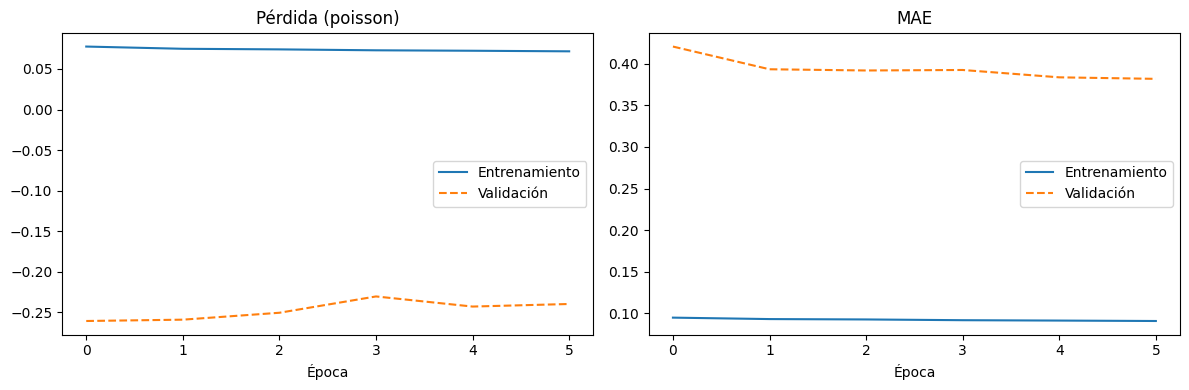

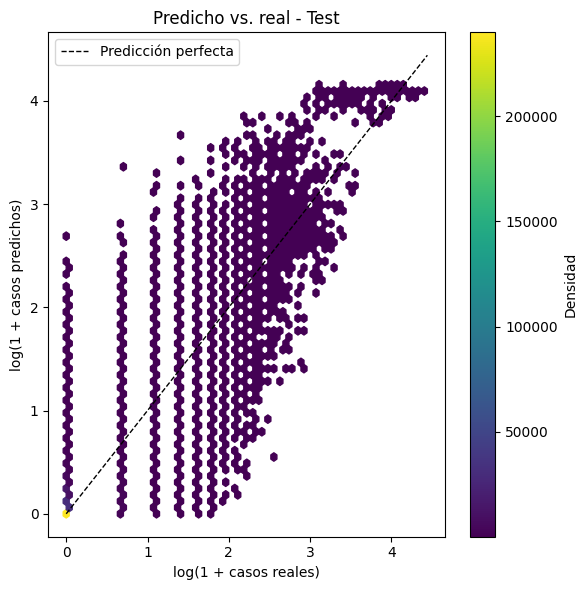

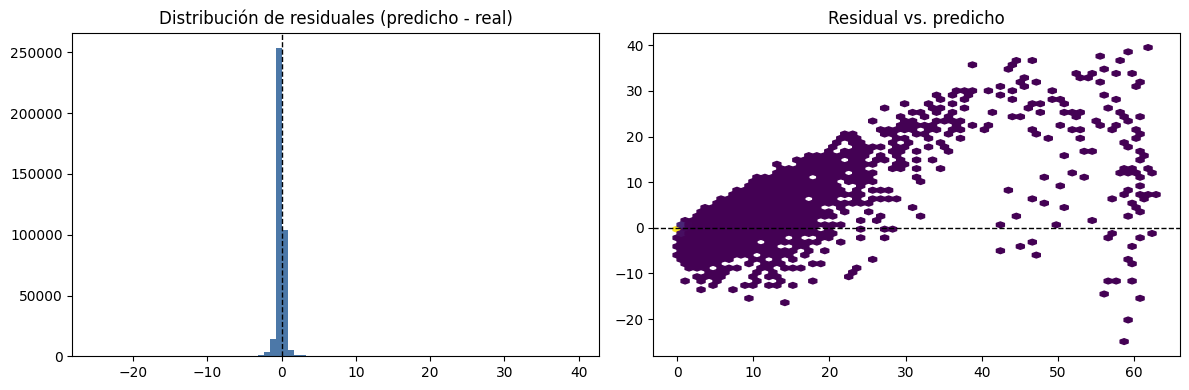

In [56]:
import json
import tempfile
import matplotlib.pyplot as plt

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_metrics({f"val_{k}": v for k, v in metricas_validation.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in metricas_test.items()})

    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)

        # Curvas de perdida (train vs validation)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(historial_final.history["loss"], linestyle="-", label="Entrenamiento")
        axes[0].plot(historial_final.history["val_loss"], linestyle="--", label="Validación")
        axes[0].set_title("Pérdida (poisson)"); axes[0].set_xlabel("Época"); axes[0].legend()
        axes[1].plot(historial_final.history["mae"], linestyle="-", label="Entrenamiento")
        axes[1].plot(historial_final.history["val_mae"], linestyle="--", label="Validación")
        axes[1].set_title("MAE"); axes[1].set_xlabel("Época"); axes[1].legend()
        plt.tight_layout()
        fig.savefig(tmp / "curva_perdida.png", dpi=150)
        mlflow.log_artifact(str(tmp / "curva_perdida.png"))
        plt.show()

        # Predicho vs. real (test) - hexbin en escala log1p por el sesgo/ceros
        fig, ax = plt.subplots(figsize=(6, 6))
        maximo = max(y_test.max(), pred_test.max())
        hb = ax.hexbin(np.log1p(y_test), np.log1p(pred_test), gridsize=60, cmap="viridis", mincnt=1)
        ax.plot([0, np.log1p(maximo)], [0, np.log1p(maximo)], "k--", linewidth=1, label="Predicción perfecta")
        ax.set_xlabel("log(1 + casos reales)"); ax.set_ylabel("log(1 + casos predichos)")
        ax.set_title("Predicho vs. real - Test"); ax.legend()
        fig.colorbar(hb, label="Densidad")
        plt.tight_layout()
        fig.savefig(tmp / "predicho_vs_real.png", dpi=150)
        mlflow.log_artifact(str(tmp / "predicho_vs_real.png"))
        plt.show()

        # Residuales
        residuales = pred_test - y_test
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(residuales, bins=80, color="#4C78A8")
        axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
        axes[0].set_title("Distribución de residuales (predicho - real)")
        axes[1].hexbin(pred_test, residuales, gridsize=60, cmap="viridis", mincnt=1)
        axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
        axes[1].set_title("Residual vs. predicho")
        plt.tight_layout()
        fig.savefig(tmp / "residuales.png", dpi=150)
        mlflow.log_artifact(str(tmp / "residuales.png"))
        plt.show()

        (tmp / "metricas.json").write_text(json.dumps(
            {"validation": metricas_validation, "test": metricas_test}, indent=2
        ))
        mlflow.log_artifact(str(tmp / "metricas.json"))

In [57]:
import pandas as pd

df_test_eval = pd.DataFrame({
    "mpio_cdpmp": municipios_seq[mask_test],
    "fecha_objetivo": fechas_target[mask_test],
    "real": y_test,
    "predicho": pred_test,
})
df_test_eval["error_abs"] = (df_test_eval["predicho"] - df_test_eval["real"]).abs()

resumen_municipio = (
    df_test_eval.groupby("mpio_cdpmp")
    .agg(casos_reales_totales=("real", "sum"), mae=("error_abs", "mean"), n_observaciones=("real", "size"))
    .reset_index()
)

print("Top 15 municipios con mayor error absoluto promedio:")
print(resumen_municipio.sort_values("mae", ascending=False).head(15).to_string(index=False))
print("\nTop 15 municipios con mayor carga de casos reales (foco del negocio):")
print(resumen_municipio.sort_values("casos_reales_totales", ascending=False).head(15).to_string(index=False))

with mlflow.start_run(run_id=final_run_id):
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        resumen_municipio.to_csv(tmp / "metricas_por_municipio.csv", index=False)
        mlflow.log_artifact(str(tmp / "metricas_por_municipio.csv"))

Top 15 municipios con mayor error absoluto promedio:
mpio_cdpmp  casos_reales_totales      mae  n_observaciones
     13001                5312.0 7.853187              344
     08001                3157.0 6.474607              344
     76001                1576.0 5.318891              344
     54001                3770.0 5.131864              344
     23001                2235.0 4.320768              344
     50001                2334.0 3.851200              344
     08758                1538.0 3.619277              344
     68001                1812.0 2.903395              344
     41001                1349.0 2.531422              344
     20001                1021.0 2.392021              344
     25307                 983.0 2.335023              344
     73001                 775.0 2.249925              344
     18753                 887.0 2.121288              344
     25290                 407.0 2.092802              344
     70001                 692.0 2.044231              344

To

# 14. Guardado de artefactos
---
Se guarda en `models/lstm/` (ya existe como placeholder en el repo) todo lo necesario para que un notebook o servicio de inferencia separado reconstruya el pipeline de preprocesamiento sin volver a tocar los datos crudos: el modelo (`.keras`), el `StandardScaler`, las medianas de imputación, el mapeo municipio→id, la lista de features y los hiperparámetros ganadores.

Nota: opcionalmente se puede correr manualmente `git add models/lstm && git commit && git push` para dejar los artefactos versionados en el repo (no se automatiza aquí para no ejecutar git sin confirmación explícita).

In [58]:
import json
import joblib

RUTA_MODELOS.mkdir(parents=True, exist_ok=True)

modelo_lstm_final.save(RUTA_MODELOS / "modelo_lstm.keras")           # formato nativo Keras
joblib.dump(scaler, RUTA_MODELOS / "scaler.joblib")                  # ajustado solo en train (Seccion 5)
joblib.dump(medianas_train, RUTA_MODELOS / "medianas_train.joblib")  # idem

with open(RUTA_MODELOS / "municipio_to_id.json", "w") as f:
    json.dump(municipio_to_id, f, indent=2)

with open(RUTA_MODELOS / "features_lstm.json", "w") as f:
    json.dump(features_lstm, f, indent=2)

config = {
    "lookback": LOOKBACK, "horizon": HORIZON, "n_municipios": N_MUNICIPIOS,
    "batch_size": BATCH_SIZE, "hiperparametros": mejores_hp.values,
    "mlflow_run_id": final_run_id,
}
with open(RUTA_MODELOS / "hiperparametros.json", "w") as f:
    json.dump(config, f, indent=2)

print("Artefactos guardados en:", RUTA_MODELOS)
for archivo in sorted(RUTA_MODELOS.glob("*")):
    print(" -", archivo.name)

# Se adjuntan tambien a la corrida final de MLflow
with mlflow.start_run(run_id=final_run_id):
    for archivo in RUTA_MODELOS.glob("*"):
        if archivo.is_file():
            mlflow.log_artifact(str(archivo), artifact_path="artefactos_lstm")

Artefactos guardados en: /content/microproyecto-tema3/models/lstm
 - features_lstm.json
 - hiperparametros.json
 - lstm_checkpoint.keras
 - medianas_train.joblib
 - modelo_lstm.keras
 - municipio_to_id.json
 - scaler.joblib


In [59]:
if IN_COLAB and DRIVE_ARTIFACTS is not None:
    import shutil
    destino = DRIVE_ARTIFACTS / "models_lstm"
    shutil.copytree(RUTA_MODELOS, destino, dirs_exist_ok=True)
    print("Copia de respaldo en Drive:", destino)

Copia de respaldo en Drive: /content/drive/MyDrive/sat-dengue-lstm/models_lstm


# 15. Inferencia
---
Función que, dado un municipio (código DIVIPOLA `mpio_cdpmp`) y una fecha de referencia, construye la ventana de 28 días más reciente disponible, aplica el **mismo** pipeline de preprocesamiento de la Sección 5 (imputación con medianas de train, escalado con el scaler de train, id de municipio con fallback a "desconocido"), y predice los casos esperados 21 días después.

Limitación conocida para producción real (no resuelta aquí): en un despliegue en vivo, los últimos días de clima (ERA5) y de casos (SIVIGILA) suelen llegar con rezago de reporte, así que la "ventana más reciente disponible" puede no llegar hasta la fecha de hoy.

In [60]:
def construir_ventana(df_features_crudo, mpio_cdpmp, fecha_referencia, lookback=LOOKBACK):
    fecha_referencia = pd.Timestamp(fecha_referencia)
    ventana = (
        df_features_crudo[
            (df_features_crudo["mpio_cdpmp"] == mpio_cdpmp)
            & (df_features_crudo["date"] <= fecha_referencia)
        ]
        .sort_values("date")
        .tail(lookback)
    )
    if len(ventana) < lookback:
        raise ValueError(
            f"Solo hay {len(ventana)} días disponibles para {mpio_cdpmp} "
            f"hasta {fecha_referencia.date()}; se necesitan {lookback}."
        )
    return ventana

def preprocesar_ventana(ventana, medianas, scaler, columnas=features_lstm):
    datos = ventana[columnas].fillna(medianas)
    return scaler.transform(datos).astype("float32")

def id_municipio(mpio_cdpmp, mapeo):
    return mapeo.get(mpio_cdpmp, 0)

def predecir_casos(modelo, df_features_crudo, mpio_cdpmp, fecha_referencia,
                    medianas, scaler, mapeo_municipio, lookback=LOOKBACK, horizon=HORIZON):
    ventana = construir_ventana(df_features_crudo, mpio_cdpmp, fecha_referencia, lookback)
    secuencia = preprocesar_ventana(ventana, medianas, scaler).reshape(1, lookback, len(features_lstm))
    municipio_id = np.array([[id_municipio(mpio_cdpmp, mapeo_municipio)]], dtype="int32")

    prediccion = modelo.predict({"sequence": secuencia, "municipio": municipio_id}, verbose=0)
    fecha_objetivo = ventana["date"].max() + pd.Timedelta(days=horizon)
    return {
        "mpio_cdpmp": mpio_cdpmp,
        "fecha_referencia": ventana["date"].max(),
        "fecha_objetivo": fecha_objetivo,
        "casos_esperados": float(prediccion.ravel()[0]),
    }

In [61]:
idx_demo = np.argmax(y_test)
municipio_demo = municipios_seq[mask_test][idx_demo]
fecha_objetivo_demo = fechas_target[mask_test][idx_demo]
fecha_referencia_demo = fecha_objetivo_demo - pd.Timedelta(days=HORIZON)

resultado = predecir_casos(
    modelo_lstm_final, dataset_lstm, municipio_demo, fecha_referencia_demo,
    medianas_train, scaler, municipio_to_id,
)

print("Predicción end-to-end:", resultado)
print("Predicción vectorizada (Sección 13):", float(pred_test[idx_demo]))
print("Valor real observado:", float(y_test[idx_demo]))

Predicción end-to-end: {'mpio_cdpmp': np.str_('13001'), 'fecha_referencia': Timestamp('2025-01-11 00:00:00'), 'fecha_objetivo': Timestamp('2025-02-01 00:00:00'), 'casos_esperados': 59.06085205078125}
Predicción vectorizada (Sección 13): 59.06626510620117
Valor real observado: 84.0


In [62]:
# Reconstruccion 100% desde disco, sin depender de variables en memoria
modelo_cargado = tf.keras.models.load_model(RUTA_MODELOS / "modelo_lstm.keras")
scaler_cargado = joblib.load(RUTA_MODELOS / "scaler.joblib")
medianas_cargadas = joblib.load(RUTA_MODELOS / "medianas_train.joblib")
with open(RUTA_MODELOS / "municipio_to_id.json") as f:
    municipio_to_id_cargado = json.load(f)

resultado_cargado = predecir_casos(
    modelo_cargado, dataset_lstm, municipio_demo, fecha_referencia_demo,
    medianas_cargadas, scaler_cargado, municipio_to_id_cargado,
)
print(resultado_cargado)

{'mpio_cdpmp': np.str_('13001'), 'fecha_referencia': Timestamp('2025-01-11 00:00:00'), 'fecha_objetivo': Timestamp('2025-02-01 00:00:00'), 'casos_esperados': 59.06085205078125}


# 16. Guardar el notebook y subir todo al repositorio
---
El notebook que corre en la interfaz de Colab **no es el mismo archivo** que el bootstrap clonó en `/content/microproyecto-tema3` — son dos copias independientes. Por eso, antes de hacer `git push`, hay que:

1. Capturar el notebook *tal como está corriendo ahora* (con todas sus salidas) usando una API interna de Colab (`google.colab._message`), y volcarlo sobre el archivo clonado.
2. Revisar qué va a quedar commiteado (`git status`).
3. Agregar solo lo que interesa versionar (el notebook + `models/lstm/`, no `mlruns/` ni cachés del tuner), commitear y subir a la rama `sergio-dev`.

**Requisito:** un secreto de Colab llamado `GITHUB_TOKEN` con un [personal access token](https://github.com/settings/tokens) que tenga permiso de escritura sobre `j-mauro-r/microproyecto-tema3` (scope `repo` en un token clásico, o "Contents: Read and write" en uno fine-grained). Se usa solo para esta subida, nunca queda escrito en el `.git/config`.

In [ ]:
import json

ruta_notebook = REPO_DIR / "notebooks" / "sergio-data-exploration-lstm.ipynb"

if IN_COLAB:
    try:
        from google.colab import _message
        notebook_actual = _message.blocking_request("get_ipynb", timeout_sec=60)["ipynb"]
        ruta_notebook.write_text(json.dumps(notebook_actual, indent=1, ensure_ascii=False))
        print("Notebook (con sus salidas actuales) volcado en:", ruta_notebook)
    except Exception as e:
        print(
            "No se pudo capturar el notebook automaticamente:", e, "\n"
            "Alternativa manual: Archivo > Guardar una copia en GitHub, "
            "o Archivo > Descargar > Descargar .ipynb y reemplazar el archivo "
            f"en {ruta_notebook} a mano."
        )
else:
    print("Entorno local: el archivo del notebook ya esta actualizado, no hace falta este paso.")